In [5]:
#2.2 编程题
import numpy as np

#1.创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("X矩阵（3×4 标准正态分布）:")
print(X)
print()

#2.创建一个形状为 4 × 2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("Y矩阵（4×2 全1矩阵）:")
print(Y)
print()

#3.计算矩阵乘法 Z = X × Y
Z = X @ Y
print("Z矩阵:\n", Z)
print()

#4.输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
print("Z[0,1] =", Z[0, 1])
print("第2行:", Z[1])
print()

#5.计算 Z 的 Frobenius 范数
frob_norm = np.linalg.norm(Z)
print("Frobenius norm:", frob_norm)

X矩阵（3×4 标准正态分布）:
[[ 0.6108019  -0.57939488 -0.15980851 -0.75338566]
 [ 0.37314314 -0.42939692  0.72034424  1.15331049]
 [-0.37917937 -1.04050925 -1.52550795  0.24345189]]

Y矩阵（4×2 全1矩阵）:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z矩阵:
 [[-0.88178715 -0.88178715]
 [ 1.81740094  1.81740094]
 [-2.70174469 -2.70174469]]

Z[0,1] = -0.8817871494601816
第2行: [1.81740094 1.81740094]

Frobenius norm: 4.770727221969828


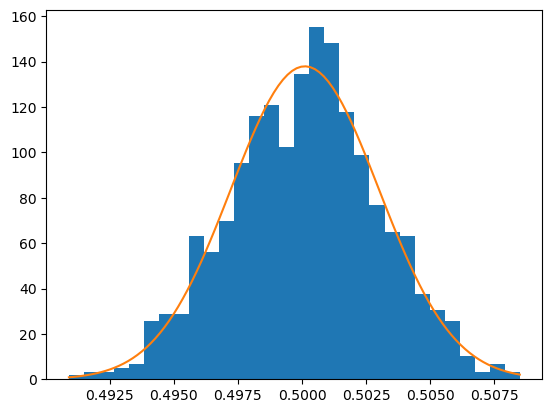

方差: 8.363327942491132e-06


In [7]:
#3.2 编程题
import numpy as np
import matplotlib.pyplot as plt

#1.生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000次，每次计算这 n 个变量的均值
n, m = 10000, 1000
means = []
for _ in range(m):
    samples = np.random.rand(n)
    means.append(np.mean(samples))

#2.绘制这 1000 个均值的直方图
plt.hist(means, bins=30, density=True)

#并叠加理论正态分布的概率密度曲线。
mu, sigma = np.mean(means), np.std(means)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, 1/(sigma*np.sqrt(2*np.pi))*np.exp(-0.5*((x-mu)/sigma)**2))

plt.show()
#3.计算这些均值的实际方差
print("方差:", np.var(means))

In [12]:
#4.2 编程题
import numpy as np
import torch

#1.定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b^2
x = float(input("请输入 x: "))#x=2
w1 = float(input("请输入 w1: "))#w1=1.5
w2 = float(input("请输入 w2: "))#w2=0.5

#2.给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果
a = x * w1
b = a + w2
L = b ** 2
print("\n前向计算结果 L =", L)

##3.手动（按链式法则）计算损失 L 对 w1, w2 的梯度
dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db * 1

print("\n前向结果:")
print("dL/dw1 =", dL_dw1)
print("dL/dw2 =", dL_dw2)

#并验证与自动微分工具（如 torch.autograd）的结果是否一致
x_t = torch.tensor(x, requires_grad=True)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("\ntorch.autograd 梯度:")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())


前向计算结果 L = 12.25

前向结果:
dL/dw1 = 14.0
dL/dw2 = 7.0

torch.autograd 梯度:
dL/dw1 = 14.0
dL/dw2 = 7.0


In [13]:
#5.2 编程题 从零实现 softmax 回归对手写数字（MNIST）进行分类
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

#1.使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集
digits = load_digits()
X = digits.images.reshape((len(digits.images), -1)) / 16.0
y = digits.target

#2.将图像展平为向量，对标签进行 one‑hot 编码
def one_hot(y, num_classes=10):
    out = np.zeros((y.shape[0], num_classes))
    out[np.arange(y.shape[0]), y] = 1
    return out

y_onehot = one_hot(y)

#3.实现 softmax 函数、交叉熵损失函数
#划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

#初始化参数
num_features = X_train.shape[1]
num_classes = 10
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros(num_classes)

#softmax 函数
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

#交叉熵损失函数
def cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

#4.使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个epoch
batch_size = 32
lr = 0.1
epochs = 50

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        logits = X_batch @ W + b
        y_pred = softmax(logits)

        grad_logits = (y_pred - y_batch) / batch_size
        dW = X_batch.T @ grad_logits
        db = np.sum(grad_logits, axis=0)

        W -= lr * dW
        b -= lr * db

#5.输出测试集上的准确率
logits_test = X_test @ W + b
y_pred_labels = np.argmax(softmax(logits_test), axis=1)
y_true_labels = np.argmax(y_test, axis=1)

acc = np.mean(y_pred_labels == y_true_labels)
print("测试集准确率:", acc)

测试集准确率: 0.9611111111111111


测试集准确率: 0.98


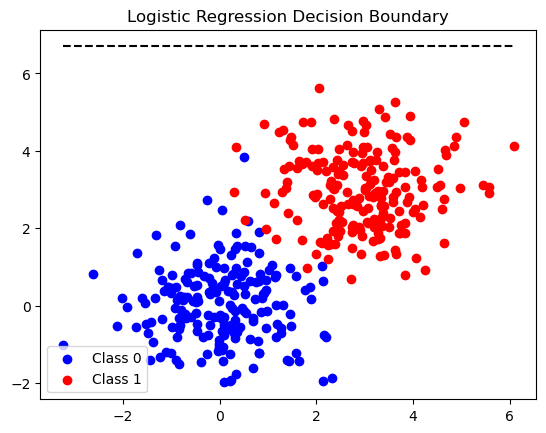

In [ ]:
#6.2 编程题 实现二分类逻辑回归模型
import numpy as np
import matplotlib.pyplot as plt

#1.生成两类线性可分的数据：每类 200 个样本，特征维度为 2
np.random.seed(42)
class0 = np.random.randn(200, 2) + np.array([0, 0])
class1 = np.random.randn(200, 2) + np.array([3, 3])

X = np.vstack([class0, class1])
y = np.hstack([np.zeros(200), np.ones(200)])

#2.定义 sigmoid 函数和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#3.使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b
#初始化参数
w = np.random.randn(2)
b = 0.0
lr = 0.1

#梯度下降
for i in range(1000):
    z = X @ w + b
    y_hat = sigmoid(z)

    dw = (1 / len(X)) * X.T @ (y_hat - y)
    db = np.mean(y_hat - y)

    w -= lr * dw
    b -= lr * db

#4.绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类准确率
#测试集
test_class0 = np.random.randn(50, 2) + np.array([0, 0])
test_class1 = np.random.randn(50, 2) + np.array([3, 3])
X_test = np.vstack([test_class0, test_class1])
y_test = np.hstack([np.zeros(50), np.ones(50)])

z_test = X_test @ w + b
y_pred = (sigmoid(z_test) > 0.5).astype(int)
acc = np.mean(y_pred == y_test)
print("测试集准确率:", acc)

#绘制决策边界
plt.scatter(class0[:,0], class0[:,1], c='blue', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], c='red', label='Class 1')

x_min, x_max = X[:,0].min(), X[:,0].max()
boundary = -(w[0]*x_min + b) / w[1]
plt.plot([x_min, x_max], [boundary, boundary], 'k--')
plt.legend()
plt.title("Logistic Regression Decision Boundary")
plt.show()